# Dacon E-Commerce Dataset - Bronze 등급 세부 분석

---

## 분석 개요

RFM 세그먼테이션에서 도출된 **Bronze(재방문율 26.3%)** 를 대상으로 이탈 구조와 재활성화 가능성을 심층 분석하고, Silver 전환 전략과 이탈 방어 방안을 제시한다.

| 항목 | 내용 |
|------|------|
| 분석 대상 | Bronze |
| 분석 기간 | 2019-01-01 - 2019-12-31 |
| 고객 수 | 699명 (47.6%) |
| 매출 기여 | 전체 매출의 11.0% |

---

## 등급 프로파일

RFM 점수(20-100)는 R·F·M 점수(각 1-5)에 PCA 가중치(R 20.1% / F 33.9% / M 46.0%)를 적용해 산출한다.

| | Bronze |
|---|---|
| RFM 점수 기준 | 20점 이상 - 50점 미만 |
| 재방문율 | 26.3% |
| 1인당 지출 | `$758` |

---

## 세그먼트 구성

| 세그먼트 | 비중 | 그룹 | 정의 |
|---------|:----:|:----:|------|
| 휴면 고객 | **42.3%** | 재활성화군 | 과거 구매 이력 있으나 장기 미방문 상태 |
| 신규 고객 | 31.5% | 온보딩군 | 첫 구매 후 재방문 없이 Bronze에 머문 상태 |
| 이탈 고객 | 18.5% | 이탈군 | 장기간 재방문 없이 이탈한 고객 |
| 이탈 조짐 고객 | 6.7% | 재활성화군 | 재방문 이력 있으나 최근 방문 감소 중 |
| 가망 고객 | 0.6% | 재활성화군 | 재방문 이력 있고 최근성 높아 Silver 전환 후보 |
| 놓치면 안될 고객 | 0.4% | 이탈군 | 고가치 구매 이력 있으나 장기 미방문으로 이탈 위험 |

재활성화군(49.6%) · 온보딩군(31.5%) · 이탈군(18.9%)

---

## 분석 배경

Bronze는 전체 고객의 47.6%(699명)로 가장 많지만 매출 기여는 11.0%에 그친다.  
재방문율 26.3%로 4명 중 3명이 단 하루만 구매하고 재방문하지 않아, 이탈 위험이 가장 높은 등급이다.  
이탈 세그먼트(이탈 고객 18.5% + 놓치면 안될 고객 0.4%)가 18.9%(132명)이고, 신규 고객 31.5%(220명)이 재방문 없이 잔류하고 있다.

---

## 핵심 질문

**왜 4명 중 3명이 재방문하지 않는가? 재활성화 가능한 고객은 누구인가? Silver 전환은 어떻게 가능한가?**

| 가설 | 내용 |
|------|------|
| 가설 1 | Bronze의 낮은 재방문율(26.3%)은 이탈 고객의 낮은 재방문율이 전체를 끌어내리며, 세그먼트별로 큰 편차가 존재할 것이다 (RFM 점수 구간별 심화 포함) |
| 가설 2 | Bronze 세그먼트별 Silver 전환 갭은 Recency보다 Monetary·Frequency에 의해 결정되며, Recency가 길어도 M·F가 높은 세그먼트가 Silver 전환 갭이 더 작을 것이다 |
| 가설 3 | Bronze 이탈 조짐(Recency > 90일) 고객의 마지막 구매가 특정 시기에 집중되며, 세그먼트별 이탈 시기도 그룹별로 분리될 것이다 |


In [1]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os

load_dotenv()
engine = create_engine(
    f"mysql+mysqlconnector://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}/{os.getenv('DB_NAME')}"
)

# 분석 SQL은 ../sql/04_segment_bronze.sql 에 모으고 `-- name:` 마커로 구분한다.
import re
from pathlib import Path
from sqlalchemy import text

SQL_FILE = Path('../sql/04_segment_bronze.sql')

def load_queries(path):
    """`-- name: 이름 | 설명` 마커로 SQL을 쪼개 {이름: 쿼리}로 반환."""
    body = Path(path).read_text(encoding='utf-8')
    parts = re.split(r'(?m)^--\s*name:\s*(\w+).*$', body)
    return {parts[i]: parts[i + 1].strip() for i in range(1, len(parts), 2)}

Q = load_queries(SQL_FILE)

def run(name, **kwargs):
    """이름으로 SELECT 쿼리를 실행해 DataFrame 반환."""
    return pd.read_sql(Q[name], engine, **kwargs)

def execute(name):
    """이름으로 DDL(세미콜론 구분)을 실행."""
    with engine.begin() as conn:
        for stmt in [s for s in Q[name].split(';') if s.strip()]:
            conn.execute(text(stmt))

---
## 데이터 로드

`rfm_result` 테이블에 저장된 세그먼트를 로드하여 Bronze 고객의 RFM 지표와 세그먼트를 한 번에 불러온다.

In [2]:
bronze_rfm = run('bronze_rfm')
bronze_rfm.head()

,고객ID,세그먼트,Recency,Frequency,Monetary,R,F,M,RFM_score
0,USER_0000,신규 고객,107,1,24.98,3,1,1,28.043368
1,USER_0002,신규 고객,73,8,1492.41,4,2,2,48.043368
2,USER_0005,이탈 조짐 고객,130,3,688.02,3,1,2,37.243058
3,USER_0007,신규 고객,24,5,492.60,5,1,1,36.086737
4,USER_0010,이탈 조짐 고객,156,6,579.40,3,2,1,34.821995


In [3]:
seg_color = {
    '휴면 고객': '#95a5a6',
    '신규 고객': '#3498db',
    '이탈 고객': '#e74c3c',
    '이탈 조짐 고객': '#e67e22',
    '가망 고객': '#27ae60',
    '놓치면 안될 고객': '#8e44ad',
}
seg_group_map = {
    '휴면 고객': '재활성화군',
    '신규 고객': '온보딩군',
    '이탈 고객': '이탈군',
    '이탈 조짐 고객': '재활성화군',
    '가망 고객': '재활성화군',
    '놓치면 안될 고객': '이탈군',
}

seg_overview = (
    bronze_rfm.groupby('세그먼트')
    .agg(
        고객수=('고객ID', 'count'),
        R_중앙값=('R', 'median'),
        F_중앙값=('F', 'median'),
        M_중앙값=('M', 'median'),
        RFM_score_중앙값=('RFM_score', 'median'),
        Recency_중앙값=('Recency', 'median'),
        Frequency_중앙값=('Frequency', 'median'),
        Monetary_중앙값=('Monetary', 'median'),
    )
    .round(2)
    .reset_index()
)
seg_overview['그룹'] = seg_overview['세그먼트'].map(seg_group_map)
seg_overview = seg_overview.sort_values('RFM_score_중앙값', ascending=False).reset_index(drop=True)
seg_overview

,세그먼트,고객수,R_중앙값,F_중앙값,M_중앙값,RFM_score_중앙값,Recency_중앙값,Frequency_중앙값,Monetary_중앙값,그룹
0,가망 고객,4,5.0,2.0,1.0,42.87,22.0,6.5,592.68,재활성화군
1,놓치면 안될 고객,3,1.0,1.0,3.0,38.40,268.0,4.0,2097.92,이탈군
2,휴면 고객,296,2.0,2.0,2.0,37.99,202.0,7.0,1013.12,재활성화군
3,신규 고객,220,4.0,1.0,1.0,36.09,81.0,3.0,440.35,온보딩군
4,이탈 조짐 고객,47,3.0,2.0,1.0,34.82,144.0,7.0,579.40,재활성화군
5,이탈 고객,129,1.0,1.0,1.0,20.00,290.0,3.0,346.67,이탈군


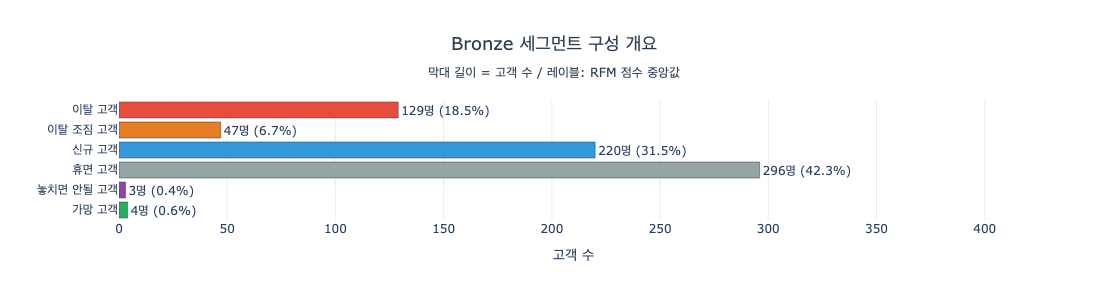

In [4]:
main_segs = ['휴면 고객', '신규 고객', '이탈 고객', '이탈 조짐 고객', '가망 고객', '놓치면 안될 고객']
fig = go.Figure()
for _, row in seg_overview[seg_overview['세그먼트'].isin(main_segs)].iterrows():
    seg = row['세그먼트']
    fig.add_trace(go.Bar(
        x=[row['고객수']],
        y=[seg],
        orientation='h',
        marker=dict(color=seg_color.get(seg, '#cccccc'), line=dict(color='#2c3e50', width=0.5)),
        text=[f"{row['고객수']}명 ({row['고객수']/699*100:.1f}%)"],
        textposition='outside',
        showlegend=False,
    ))

fig.update_layout(
    title=dict(
        text='Bronze 세그먼트 구성 개요<br><sub>막대 길이 = 고객 수 / 레이블: RFM 점수 중앙값</sub>',
        x=0.5, xanchor='center', font=dict(size=18, color='#2c3e50')
    ),
    plot_bgcolor='white',
    xaxis=dict(title='고객 수', range=[0, 420], gridcolor='#ececec'),
    yaxis=dict(title=''),
    height=300,
)
fig.show()

> ⚠️ **분석 범위**: 가망 고객(4명)·놓치면 안될 고객(3명)은 표본이 너무 적어 이하 가설 검증 분석에서 제외한다. 시각화에서는 참고용으로만 표기하며, 해당 세그먼트의 RFM 포지션과 전략은 결론 섹션에서 다룬다.

---
## 가설 1 — Bronze 재방문율(26.3%)은 이탈 고객의 낮은 재방문율이 전체를 끌어내린다

> **가설 1**: Bronze의 낮은 재방문율(26.3%)은 이탈 고객(129명, 18.5%)의 낮은 재방문율이 Bronze 전체를 끌어내리기 때문이며, 세그먼트별로 큰 편차가 존재할 것이다.
>
> - 근거: Silver 분석에서 세그먼트별 재방문율 편차(46.3%-64.3%)가 확인된 패턴 — Bronze에도 유사하게 적용될 것
> - 검증 1: 세그먼트별 재방문율 및 Recency 분포 비교
> - 검증 2: RFM 점수 구간별 재방문율 (20-30 / 30-40 / 40-50) — 단조 증가 여부 확인

In [5]:
visit_h1 = run('visit_days_by_segment')
visit_h1 = visit_h1.merge(bronze_rfm[['고객ID', 'Recency', 'R']], on='고객ID')
visit_h1['재방문'] = visit_h1['방문일수'] > 1
visit_h1['그룹'] = visit_h1['세그먼트'].map(seg_group_map)

main4 = ['휴면 고객', '신규 고객', '이탈 고객', '이탈 조짐 고객']
seg_revisit = (
    visit_h1[visit_h1['세그먼트'].isin(main4)]
    .groupby('세그먼트')
    .agg(
        재방문고객=('재방문', 'sum'),
        전체고객=('재방문', 'count')
    )
    .assign(재방문율=lambda x: (x['재방문고객'] / x['전체고객'] * 100).round(1))
    .reset_index()
    .sort_values('재방문율', ascending=False)
)

h1_stats = (
    visit_h1[visit_h1['세그먼트'].isin(main4)]
    .groupby('세그먼트')[['Recency', 'R']]
    .agg(['mean', 'median'])
    .round(1)
    .reset_index()
)
h1_stats.columns = ['세그먼트', 'Recency_평균', 'Recency_중앙값', 'R_평균', 'R_중앙값']
h1_stats = (
    h1_stats
    .merge(seg_revisit[['세그먼트', '재방문율', '재방문고객', '전체고객']], on='세그먼트')
    .sort_values('재방문율', ascending=False)
    .reset_index(drop=True)
)
h1_stats

,세그먼트,Recency_평균,Recency_중앙값,R_평균,R_중앙값,재방문율,재방문고객,전체고객
0,이탈 조짐 고객,159.2,144.0,2.7,3.0,42.6,20,47
1,휴면 고객,213.7,202.0,1.9,2.0,30.1,89,296
2,신규 고객,81.5,81.0,3.9,4.0,29.5,65,220
3,이탈 고객,301.3,290.0,1.0,1.0,6.2,8,129


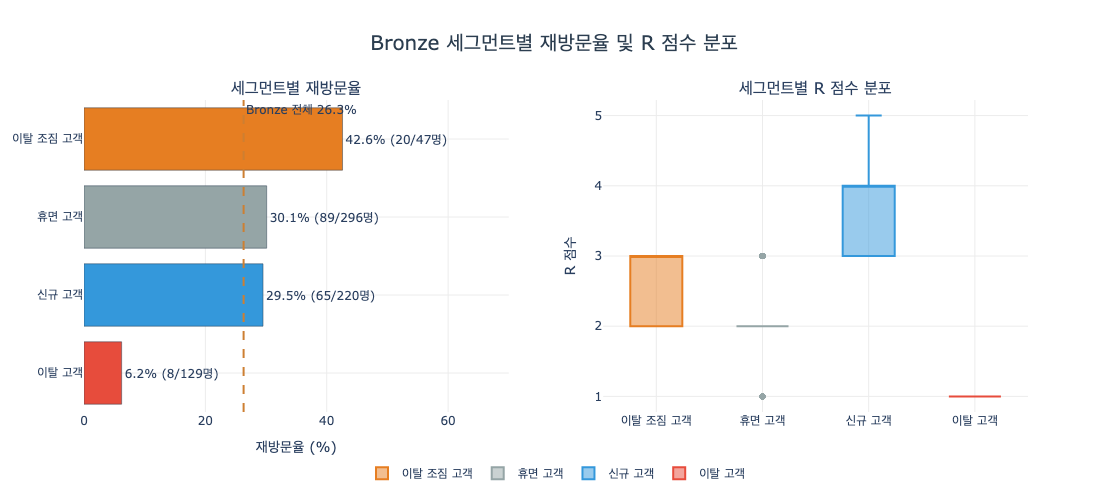

In [6]:
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=['세그먼트별 재방문율', '세그먼트별 R 점수 분포']
)

for _, row in seg_revisit.sort_values('재방문율').iterrows():
    seg = row['세그먼트']
    fig.add_trace(go.Bar(
        x=[row['재방문율']],
        y=[seg],
        orientation='h',
        marker=dict(color=seg_color.get(seg, '#cccccc'), line=dict(color='#2c3e50', width=0.5)),
        text=[f"{row['재방문율']:.1f}% ({int(row['재방문고객'])}/{int(row['전체고객'])}명)"],
        textposition='outside',
        showlegend=False,
    ), row=1, col=1)

for seg in ['이탈 조짐 고객', '휴면 고객', '신규 고객', '이탈 고객']:
    sub = visit_h1[visit_h1['세그먼트'] == seg]['R']
    fig.add_trace(go.Box(
        y=sub,
        name=seg,
        marker_color=seg_color.get(seg, '#cccccc'),
        boxpoints='outliers',
    ), row=1, col=2)

fig.add_vline(
    x=26.3, line_dash='dash', line_color='#CD7F32', line_width=2,
    annotation_text='Bronze 전체 26.3%', annotation_position='top right',
    row=1, col=1
)

fig.update_layout(
    title=dict(
        text='Bronze 세그먼트별 재방문율 및 R 점수 분포',
        font=dict(size=20, color='#2c3e50'), x=0.5, xanchor='center'
    ),
    plot_bgcolor='white',
    height=500,
    legend=dict(orientation='h', yanchor='top', y=-0.15, xanchor='center', x=0.5)
)
fig.update_xaxes(gridcolor='#ececec')
fig.update_yaxes(gridcolor='#ececec')
fig.update_xaxes(title_text='재방문율 (%)', range=[0, 70], row=1, col=1)
fig.update_yaxes(title_text='R 점수', row=1, col=2)
fig.show()

### 가설 1 심화 — RFM 점수 구간별 재방문율

In [7]:
h41_data = bronze_rfm.copy()
h41_data['점수구간'] = pd.cut(
    h41_data['RFM_score'],
    bins=[20, 30, 40, 50],
    labels=['20-30', '30-40', '40-50'],
    include_lowest=True
)

visit_data = run('visit_days_all')
h41_data = h41_data.merge(visit_data, on='고객ID')
h41_data['재방문'] = h41_data['방문일수'] > 1

h41_bin = (
    h41_data.groupby('점수구간', observed=True)
    .agg(
        고객수=('고객ID', 'count'),
        재방문수=('재방문', 'sum')
    )
    .assign(재방문율=lambda x: (x['재방문수'] / x['고객수'] * 100).round(1))
    .reset_index()
)

h41_seg = (
    h41_data.groupby(['점수구간', '세그먼트'], observed=True)
    .agg(
        고객수=('고객ID', 'count'),
        재방문수=('재방문', 'sum')
    )
    .assign(재방문율=lambda x: (x['재방문수'] / x['고객수'] * 100).round(1))
    .reset_index()
    .sort_values(['점수구간', '고객수'], ascending=[True, False])
    .reset_index(drop=True)
)

In [8]:
h41_bin

,점수구간,고객수,재방문수,재방문율
0,20-30,285,43,15.1
1,30-40,241,76,31.5
2,40-50,173,65,37.6


In [9]:
h41_seg

,점수구간,세그먼트,고객수,재방문수,재방문율
0,20-30,이탈 고객,129,8,6.2
1,20-30,휴면 고객,82,13,15.9
2,20-30,신규 고객,74,22,29.7
3,30-40,휴면 고객,118,40,33.9
4,30-40,신규 고객,75,16,21.3
5,30-40,이탈 조짐 고객,46,20,43.5
6,30-40,놓치면 안될 고객,2,0,0.0
7,40-50,휴면 고객,96,36,37.5
8,40-50,신규 고객,71,27,38.0
9,40-50,가망 고객,4,2,50.0


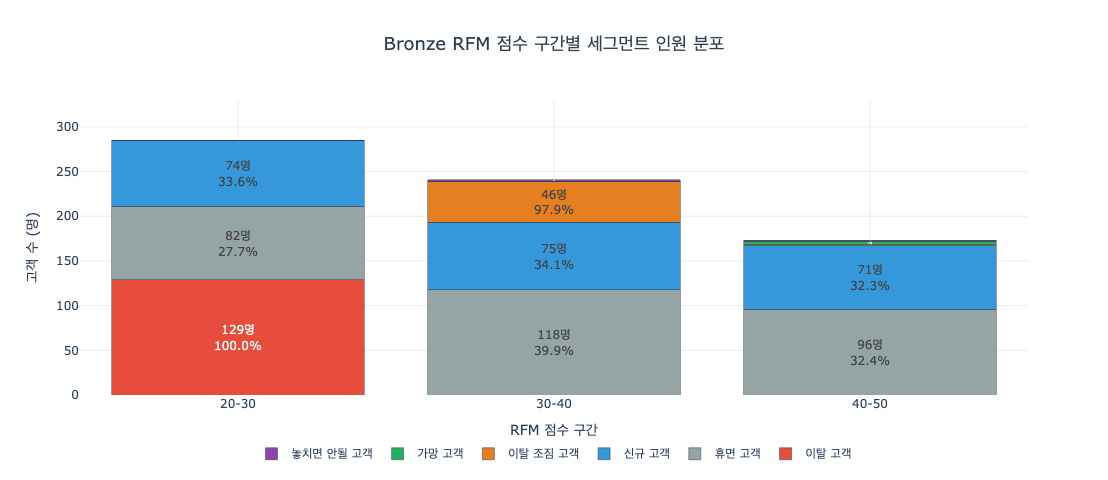

In [10]:
seg_totals = h41_seg.groupby('세그먼트')['고객수'].sum()

fig = go.Figure()

seg_order = ['이탈 고객', '휴면 고객', '신규 고객', '이탈 조짐 고객', '가망 고객', '놓치면 안될 고객']
bands = ['20-30', '30-40', '40-50']

for seg in seg_order:
    sub = h41_seg[h41_seg['세그먼트'] == seg].copy()
    sub['점수구간'] = sub['점수구간'].astype(str)
    counts = sub.set_index('점수구간')['고객수'].reindex(bands, fill_value=0)
    seg_total = seg_totals.get(seg, 1)
    text = [
        f"{int(v)}명<br>{v / seg_total * 100:.1f}%" if v >= 5 else (f"{int(v)}명" if v > 0 else '')
        for v in counts.values
    ]
    fig.add_trace(go.Bar(
        x=bands,
        y=counts.values,
        name=seg,
        marker=dict(color=seg_color.get(seg, '#cccccc'), line=dict(color='#2c3e50', width=0.5)),
        text=text,
        textposition='inside',
        insidetextanchor='middle',
    ))

fig.update_layout(
    title=dict(
        text='Bronze RFM 점수 구간별 세그먼트 인원 분포',
        font=dict(size=18, color='#2c3e50'), x=0.5, xanchor='center'
    ),
    barmode='stack',
    plot_bgcolor='white',
    height=480,
    xaxis=dict(title='RFM 점수 구간', gridcolor='#ececec'),
    yaxis=dict(title='고객 수 (명)', gridcolor='#ececec', range=[0, 330]),
    legend=dict(orientation='h', yanchor='top', y=-0.15, xanchor='center', x=0.5)
)
fig.show()

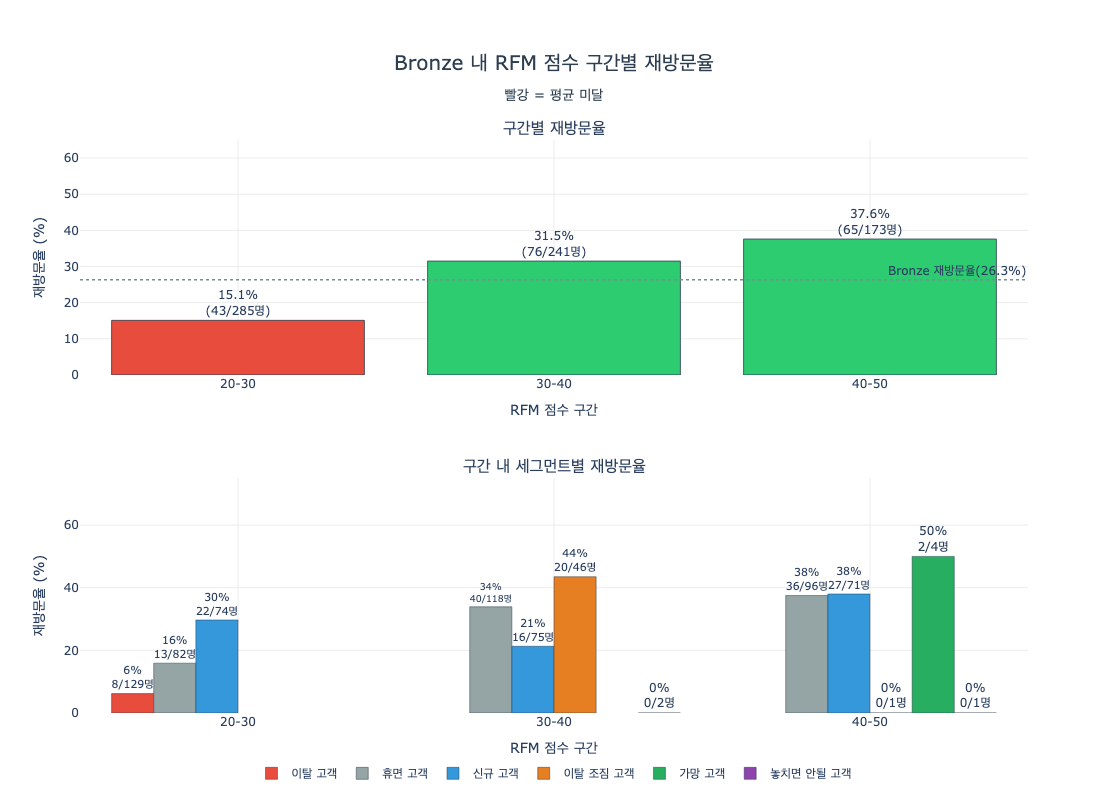

In [11]:
avg_rate = round(h41_data['재방문'].mean() * 100, 1)
colors_h41 = ['#e74c3c' if r < avg_rate else '#2ecc71' for r in h41_bin['재방문율']]

fig = make_subplots(
    rows=2, cols=1,
    subplot_titles=['구간별 재방문율', '구간 내 세그먼트별 재방문율'],
    vertical_spacing=0.18
)

fig.add_trace(go.Bar(
    x=h41_bin['점수구간'].astype(str),
    y=h41_bin['재방문율'],
    text=[
        f"{row['재방문율']:.1f}%<br>({int(row['재방문수'])}/{int(row['고객수'])}명)"
        for _, row in h41_bin.iterrows()
    ],
    textposition='outside',
    marker=dict(color=colors_h41, line=dict(color='#2c3e50', width=0.8)),
    showlegend=False,
), row=1, col=1)

seg_order = ['이탈 고객', '휴면 고객', '신규 고객', '이탈 조짐 고객', '가망 고객', '놓치면 안될 고객']
for seg in seg_order:
    sub = h41_seg[h41_seg['세그먼트'] == seg]
    if len(sub) == 0:
        continue
    fig.add_trace(go.Bar(
        x=sub['점수구간'].astype(str),
        y=sub['재방문율'],
        name=seg,
        marker=dict(color=seg_color.get(seg, '#cccccc'), line=dict(color='#2c3e50', width=0.5)),
        text=[f"{v:.0f}%<br>{n}/{t}명" for v, n, t in zip(sub['재방문율'], sub['재방문수'], sub['고객수'])],
        textposition='outside',
    ), row=2, col=1)

fig.add_hline(
    y=avg_rate,
    line_dash='dot', line_color='#7f8c8d', line_width=1.5,
    annotation_text=f'Bronze 재방문율({avg_rate}%)',
    annotation_position='top right',
    row=1, col=1
)

fig.update_layout(
    title=dict(
        text='Bronze 내 RFM 점수 구간별 재방문율<br><sub>빨강 = 평균 미달</sub>',
        font=dict(size=20, color='#2c3e50'), x=0.5, xanchor='center'
    ),
    barmode='group',
    plot_bgcolor='white',
    margin=dict(t=140),
    height=800,
    legend=dict(orientation='h', yanchor='top', y=-0.08, xanchor='center', x=0.5)
)
fig.update_xaxes(gridcolor='#ececec')
fig.update_yaxes(gridcolor='#ececec')
fig.update_xaxes(title_text='RFM 점수 구간', row=1, col=1)
fig.update_yaxes(title_text='재방문율 (%)', range=[0, 65], row=1, col=1)
fig.update_xaxes(title_text='RFM 점수 구간', row=2, col=1)
fig.update_yaxes(title_text='재방문율 (%)', range=[0, 75], row=2, col=1)
fig.show()

> ### 가설 1 검증 결과: 채택
>
> **1. 세그먼트별 재방문율**
>
> | 세그먼트 | 재방문율 | R 중앙값 | Recency 중앙값 | Recency 평균 | 그룹 |
> | :--- | :---: | :---: | :---: | :---: | :--- |
> | 이탈 조짐 고객 | **42.6%** | 3 | 144.0일 | 159.2일 | 재활성화군 |
> | 휴면 고객 | 30.1% | 2 | 202.0일 | 213.7일 | 재활성화군 |
> | 신규 고객 | 29.5% | 4 | 81.0일 | 81.5일 | 온보딩군 |
> | 이탈 고객 | **6.2%** | 1 | 290.0일 | 301.3일 | 이탈군 |
>
> **2. RFM 점수 구간별 재방문율**
>
> | 점수 구간 | 고객수 | 재방문수 | 재방문율 | 주요 세그먼트 구성 |
> | :---: | :---: | :---: | :---: | :--- |
> | 20-30 | 285명 | 43명 | **15.1%** | 이탈(129/6.2%) · 휴면(82/15.9%) · 신규(74/29.7%) |
> | 30-40 | 241명 | 76명 | **31.5%** | 휴면(118/33.9%) · 신규(75/21.3%) · 이탈조짐(46/43.5%) · 놓치면안될(2/0.0%) |
> | 40-50 | 173명 | 65명 | **37.6%** | 휴면(96/37.5%) · 신규(71/38.0%) · 가망(4/50.0%) · 놓치면안될(1/0.0%) |
>
> **핵심 요약**
> Bronze 재방문율(26.3%)은 이탈 고객의 낮은 재방문율(6.2%)이 전체를 끌어내리며, 세그먼트별(6.2%-42.6%)·RFM 점수 구간별(15.1%-37.6%) 모두 동일한 방향의 단조 증가 패턴이 확인된다.
>
> - **이탈 고객 (6.2% | R=1 | 20-30구간 집중)**: Recency 중앙값 290일로 Bronze 내 최장 미구매 기간. 129명 중 8명만 재방문 — Bronze 전체 재방문율을 끌어내리며, 20-30 구간(이탈 고객 비중 45%)의 재방문율을 15.1%로 끌어내리는 구조적 원인이다.
> - **신규 고객 (29.5% | R=4)**: Recency 중앙값 81일로 최근 가입자이나 4명 중 3명이 재방문 없음. 최근성(R=4)은 높지만 F·M이 낮아 재방문 동기가 약하다.
> - **휴면 고객 (30.1% | R=2)**: 신규(29.5%)와 유사한 재방문율이나 Recency는 202일로 훨씬 길다 — 과거 구매 이력이 일정 수준 재방문을 유지시키고 있다.
> - **이탈 조짐 고객 (42.6% | R=3 | 30-40구간 집중)**: Bronze 내 주요 세그먼트 중 최고 재방문율. 47명 중 20명이 재방문한 상태로 재활성화 잠재력이 높으며, 30-40 구간에서 최고 재방문율(43.5%)을 견인한다.
> - **RFM 점수 구간 단조 증가**: 20-30(15.1%) → 30-40(31.5%) → 40-50(37.6%) — 세그먼트 편차와 RFM 점수 구간이 동일한 방향으로 작동한다.
> - **가설 2와의 연결**: PCA 가중치(F 33.9% / M 46.0% / R 20.1%) 기준 F는 RFM 점수의 두 번째 핵심 요소다. 재방문율 향상 = Frequency 증가 = RFM 점수 상승 → Silver 전환 진전의 선순환이 성립한다.

---
## 가설 2 — Silver 전환 갭은 Recency가 아닌 Monetary·Frequency와 관련성이 높다

> **가설 2**: Bronze 세그먼트별 Silver 전환 갭(50 − RFM 중앙값)은 Recency보다 Monetary·Frequency에 의해 결정되며, Recency가 길더라도 M·F가 높은 세그먼트가 Silver 전환 갭이 더 작을 것이다.
>
> - 근거: PCA 가중치(M 46.0% > F 33.9% > R 20.1%) — RFM 점수에서 Monetary·Frequency 기여도가 Recency보다 4배가량 높음
> - 검증: 세그먼트별 RFM 포지션 확인 → Silver 갭(50 − RFM_score 중앙값) 비교 + Recency vs Monetary 분포

In [12]:
target_segs = ['휴면 고객', '신규 고객', '이탈 고객', '이탈 조짐 고객', '가망 고객', '놓치면 안될 고객']
seg_summary = (
    bronze_rfm[bronze_rfm['세그먼트'].isin(target_segs)]
    .groupby('세그먼트')[['Recency', 'Frequency', 'Monetary', 'R', 'F', 'M', 'RFM_score']]
    .agg(['median', 'mean'])
    .round(1)
    .reset_index()
)
seg_summary.columns = [
    '세그먼트',
    'Recency_중앙값', 'Recency_평균',
    'Frequency_중앙값', 'Frequency_평균',
    'Monetary_중앙값', 'Monetary_평균',
    'R_중앙값', 'R_평균',
    'F_중앙값', 'F_평균',
    'M_중앙값', 'M_평균',
    'RFM_중앙값', 'RFM_평균',
]
seg_summary['Silver_갭'] = (50 - seg_summary['RFM_중앙값']).round(1)
seg_summary = seg_summary.sort_values('Silver_갭').reset_index(drop=True)
seg_summary[['세그먼트', 'R_중앙값', 'F_중앙값', 'M_중앙값', 'RFM_중앙값', 'Silver_갭', 'Recency_중앙값', 'Monetary_중앙값']]

,세그먼트,R_중앙값,F_중앙값,M_중앙값,RFM_중앙값,Silver_갭,Recency_중앙값,Monetary_중앙값
0,가망 고객,5.0,2.0,1.0,42.9,7.1,22.0,592.7
1,놓치면 안될 고객,1.0,1.0,3.0,38.4,11.6,268.0,2097.9
2,휴면 고객,2.0,2.0,2.0,38.0,12.0,202.0,1013.1
3,신규 고객,4.0,1.0,1.0,36.1,13.9,81.0,440.4
4,이탈 조짐 고객,3.0,2.0,1.0,34.8,15.2,144.0,579.4
5,이탈 고객,1.0,1.0,1.0,20.0,30.0,290.0,346.7


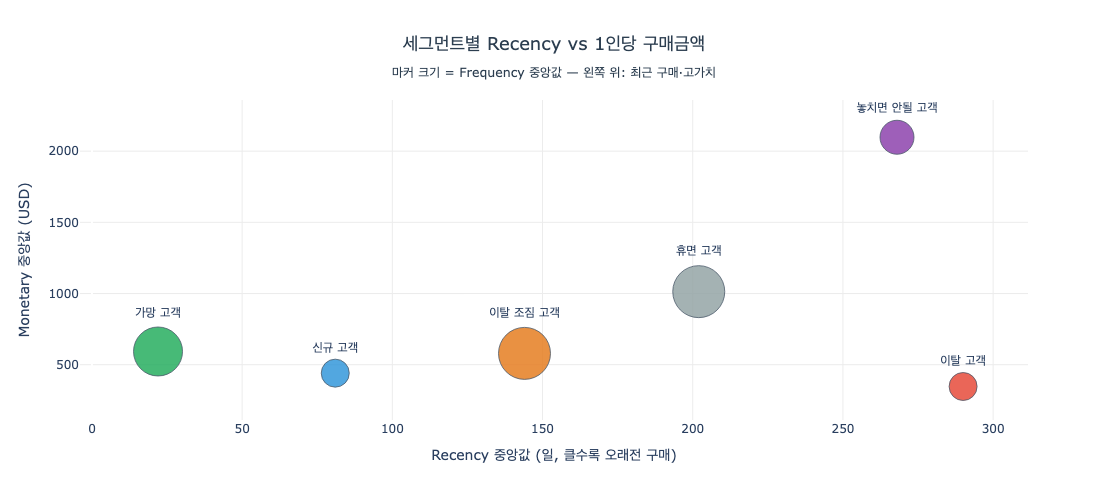

In [13]:
fig = go.Figure()
for _, row in seg_summary.iterrows():
    seg = row['세그먼트']
    fig.add_trace(go.Scatter(
        x=[row['Recency_중앙값']],
        y=[row['Monetary_중앙값']],
        mode='markers+text',
        marker=dict(
            size=row['Frequency_중앙값'] * 6 + 10,
            color=seg_color.get(seg, '#cccccc'),
            line=dict(color='#2c3e50', width=0.8),
            opacity=0.85
        ),
        text=[seg],
        textposition='top center',
        name=seg,
        showlegend=False,
    ))

fig.update_layout(
    title=dict(
        text='세그먼트별 Recency vs 1인당 구매금액<br><sub>마커 크기 = Frequency 중앙값 — 왼쪽 위: 최근 구매·고가치</sub>',
        font=dict(size=18, color='#2c3e50'), x=0.5, xanchor='center'
    ),
    xaxis=dict(title='Recency 중앙값 (일, 클수록 오래전 구매)', gridcolor='#ececec'),
    yaxis=dict(title='Monetary 중앙값 (USD)', gridcolor='#ececec'),
    plot_bgcolor='white',
    height=500,
)
fig.show()

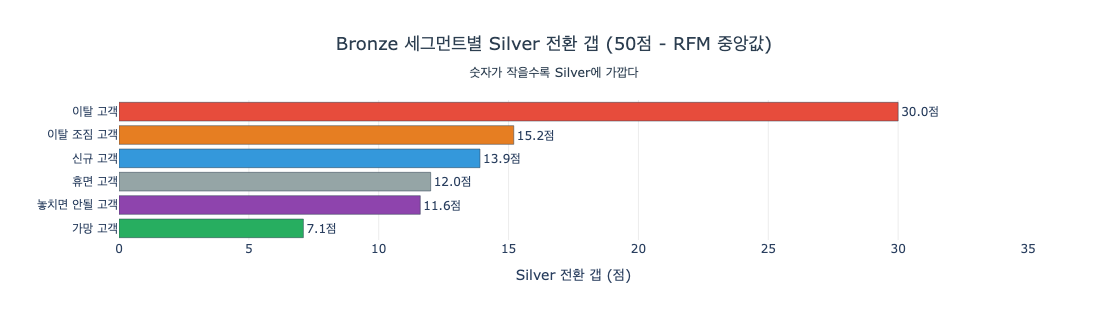

In [14]:
fig = go.Figure()
for _, row in seg_summary.iterrows():
    seg = row['세그먼트']
    fig.add_trace(go.Bar(
        x=[row['Silver_갭']],
        y=[seg],
        orientation='h',
        marker=dict(color=seg_color.get(seg, '#cccccc'), line=dict(color='#2c3e50', width=0.5)),
        text=[f"{row['Silver_갭']}점"],
        textposition='outside',
        showlegend=False,
    ))

fig.update_layout(
    title=dict(
        text='Bronze 세그먼트별 Silver 전환 갭 (50점 - RFM 중앙값)<br><sub>숫자가 작을수록 Silver에 가깝다</sub>',
        x=0.5, xanchor='center', font=dict(size=18, color='#2c3e50')
    ),
    plot_bgcolor='white',
    xaxis=dict(title='Silver 전환 갭 (점)', range=[0, 35], gridcolor='#ececec'),
    yaxis=dict(title=''),
    height=320,
)
fig.show()

### 가설 2 보충 — Bronze·Silver 총 지출 격차 원인 분해

Bronze 내부 세그먼트 비교에서 나아가, Bronze와 Silver 간 총 지출 격차(3.27배)의 원인을 Frequency와 단가로 분해한다.

In [15]:
tier_stats = run('tier_stats')
tier_stats['단가'] = (tier_stats['Monetary'] / tier_stats['Frequency']).round(1)

tier_agg = (
    tier_stats.groupby('등급')[['Monetary', 'Frequency', '단가']]
    .agg(['median', 'mean'])
    .round(1)
    .reset_index()
)
tier_agg.columns = [
    '등급',
    'Monetary_중앙값', 'Monetary_평균',
    'Frequency_중앙값', 'Frequency_평균',
    '단가_중앙값', '단가_평균',
]

bronze_row = tier_agg[tier_agg['등급'] == 'Bronze'].iloc[0]
silver_row = tier_agg[tier_agg['등급'] == 'Silver'].iloc[0]
m_ratio = round(silver_row['Monetary_평균'] / bronze_row['Monetary_평균'], 2)
f_ratio = round(silver_row['Frequency_평균'] / bronze_row['Frequency_평균'], 2)
price_ratio = round(silver_row['단가_평균'] / bronze_row['단가_평균'], 2)


In [16]:
decomp = pd.DataFrame({
    '항목': ['Monetary 격차', 'Frequency 기여', '단가 기여', '분해 검증'],
    'Silver/Bronze 배율': [
        f'{m_ratio}x',
        f'{f_ratio}x',
        f'{price_ratio}x',
        f'{round(f_ratio * price_ratio, 2)}x'
    ]
})

display(tier_agg)
display(decomp)

,등급,Monetary_중앙값,Monetary_평균,Frequency_중앙값,Frequency_평균,단가_중앙값,단가_평균
0,Bronze,629.4,757.7,5.0,5.1,127.6,150.7
1,Silver,2427.8,2475.8,15.0,15.0,162.6,180.7


,항목,Silver/Bronze 배율
0,Monetary 격차,3.27x
1,Frequency 기여,2.94x
2,단가 기여,1.2x
3,분해 검증,3.53x


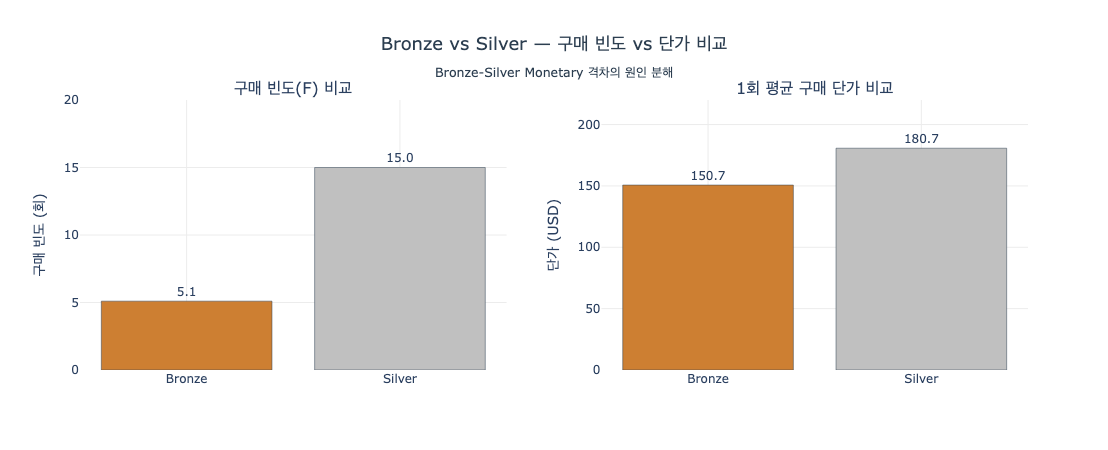

In [17]:
colors_tier = {'Bronze': '#CD7F32', 'Silver': '#C0C0C0'}

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=['구매 빈도(F) 비교', '1회 평균 구매 단가 비교']
)

for col_idx, (metric, ylab, ymax) in enumerate(
    [('Frequency_평균', '구매 빈도 (회)', 20), ('단가_평균', '단가 (USD)', 220)],
    start=1
):
    for _, row in tier_agg.iterrows():
        fig.add_trace(go.Bar(
            x=[row['등급']],
            y=[row[metric]],
            marker=dict(color=colors_tier.get(row['등급'], '#cccccc'), line=dict(color='#2c3e50', width=0.5)),
            text=[f"{row[metric]:.1f}"],
            textposition='outside',
            showlegend=False,
        ), row=1, col=col_idx)
    fig.update_yaxes(title_text=ylab, gridcolor='#ececec', range=[0, ymax], row=1, col=col_idx)

fig.update_layout(
    title=dict(
        text='Bronze vs Silver — 구매 빈도 vs 단가 비교<br><sub>Bronze-Silver Monetary 격차의 원인 분해</sub>',
        font=dict(size=18, color='#2c3e50'), x=0.5, xanchor='center'
    ),
    plot_bgcolor='white',
    height=450,
)
fig.update_xaxes(gridcolor='#ececec')
fig.show()

> ### 가설 2 검증 결과: 채택
>
>
> | 세그먼트 | 그룹 | 고객수 | RFM 중앙값 | Silver 갭 | R | F | M | Recency 순위 | 갭 순위 | Recency 중앙값 | Monetary 중앙값 |
> |---------|:----:|:-----:|:---------:|:--------:|:---:|:---:|:---:|:----------:|:------:|:-----------:|:-----------:|
> | 가망 고객 | 재활성화군 | 4명 | 42.9 | **7.1점** | 5 | 2 | 1 | **1위** | 1위 | 22.0일 | `$593` |
> | 놓치면 안될 고객 | 이탈군 | 3명 | 38.4 | **11.6점** | 1 | 1 | 3 | **5위** | 2위 | 268.0일 | **`$2,098`** |
> | 휴면 고객 | 재활성화군 | 296명 | 38.0 | **12.0점** | 2 | 2 | 2 | **4위** | 3위 | 202.0일 | **`$1,013`** |
> | 신규 고객 | 온보딩군 | 220명 | 36.1 | 13.9점 | 4 | 1 | 1 | **2위** | 4위 | 81.0일 | `$440` |
> | 이탈 조짐 고객 | 재활성화군 | 47명 | 34.8 | 15.2점 | 3 | 2 | 1 | **3위** | 5위 | 144.0일 | `$579` |
> | 이탈 고객 | 이탈군 | 129명 | 20.0 | **30.0점** | 1 | 1 | 1 | **6위** | 6위 | 290.0일 | `$347` |
>
>
> Recency 순위와 갭 순위가 일치하지 않는 세그먼트에서 가설의 핵심이 드러난다.
> Recency가 짧을수록(최근 구매) Silver에 가까워야 하지만, 실제로는 그렇지 않다.
>
> - **신규 고객**: Recency 순위 2위(짧음)이나 갭 순위 4위 — F·M=1로 낮아 Recency 이점이 상쇄된다
> - **휴면 고객**: Recency 순위 4위(긺)이나 갭 순위 3위 — F=2·M=2가 긴 침묵을 상쇄해 신규보다 Silver에 가깝다
> - **놓치면 안될 고객**: Recency 순위 5위(매우 긺)이나 갭 순위 2위 — M=3이 Recency 불리함을 압도한다
> - **이탈 조짐 고객**: Recency 순위 3위(중간)이나 갭 순위 5위 — M=1로 낮아 Recency 대비 Silver 전환 갭이 크다
> **핵심 요약**
> Silver 전환 갭은 Recency가 아닌 Monetary·Frequency와 관련성이 높다. Recency가 길어도 M·F가 높은 세그먼트가 Silver에 더 가깝다.
>
> - **휴면 고객의 역설 (n=296)**: Recency 202일로 침묵이 길지만 M=2·F=2로 갭 12.0점 — Recency가 짧은 신규(갭 13.9점)보다 Silver에 더 가깝다. 충분한 표본에서 확인된 M·F 우위의 근거.
> - **신규 고객 (n=220)**: Recency 81일이지만 F·M=1로 갭 13.9점 — 최근성이 Silver 전환을 보장하지 않는다.
> - **가망 고객 (n=4, 참고)**: R=5로 최고 최근성, 갭 7.1점 — 소표본이어서 일반화보다 RFM 포지션 파악 용도로 활용.
> - 💸 **놓치면 안될 고객 (n=3, 참고)**: Recency 268일에도 M=3 덕분에 갭 11.6점 — 소표본이어서 경향 참고 수준. Monetary `$2,098`로 고가치 이탈 방어 대상.
> - **PCA 가중치**: M(46.0%)·F(33.9%) 합산 79.9% vs R(20.1%) — 갭 순위가 M·F 크기와 대체로 일치.
> - **실질 타깃**: 볼륨·가치 기준 휴면(296명, 갭 12.0점, `$1,013`)이 최우선 — Recency 202일의 침묵을 감수하고 F·M 부스트 캠페인 집행
> - **Bronze-Silver 격차 분해(보충)**: Monetary 격차(3.27x) ≈ Frequency(2.94x) × 단가(1.20x) — 격차 대부분이 구매 빈도에서 비롯된다
>
> > ✅ **액션 아이템**: 휴면(296명, 갭 12.0점, `$1,013`) → F·M=2→3 부스트 캠페인 우선 집행 (Bronze 재활성화 최대 볼륨·최고가치)

---
## 가설 3 — Bronze 이탈 조짐(Recency > 90일) 고객의 마지막 구매는 특정 시기에 집중될 것이다

> **가설 3**: Bronze 이탈 조짐(Recency > 90일) 고객의 마지막 구매 시점이 특정 시기에 집중될 것이다.
> 나아가 세그먼트별 이탈 시기도 그룹별로 분리되어 맞춤 재활성화 타이밍 전략이 필요할 것이다.
>
> - **기준**: Gold·Silver와 동일하게 Recency > 90일 = 이탈 조짐 고객
> - **예상**:
>   - 이탈군(이탈 고객): 연초(1-4월) 집중
>   - 재활성화군(휴면 고객): 상반기(5-7월) 집중
>   - 재활성화군(이탈 조짐 고객): 여름(7-9월) 집중 (Recency 중앙값 144일 기준)
>   - 가망(4명)·놓치면 안될(3명)은 표본 부족으로 제외
> - **검증 1** (Recency 기준): 이탈 조짐 고객 월별 마지막 구매 분포 + 고객 유형별 체류 기간
> - **검증 2** (세그먼트 기준): 세그먼트별 마지막 구매 월 분포 비교

In [18]:
timing_data = run('timing')
timing_data['이탈조짐'] = timing_data['Recency'] > 90
timing_data['마지막구매월'] = pd.to_datetime(timing_data['마지막구매일']).dt.month
timing_data['체류기간'] = (
    pd.to_datetime(timing_data['마지막구매일']) - pd.to_datetime(timing_data['첫구매일'])
).dt.days

max_gap = run('max_gap')
timing_data = timing_data.merge(max_gap, on='고객ID', how='left')
timing_data['최대구매간격'] = timing_data['최대구매간격'].fillna(0).astype(int)
timing_data['복귀고객'] = (timing_data['최대구매간격'] > 90) & (~timing_data['이탈조짐'])

total = len(timing_data)
total_churn = int(timing_data['이탈조짐'].sum())
total_복귀 = int(timing_data['복귀고객'].sum())
total_정상 = total - total_churn - total_복귀

print(f"정상: {total_정상}명 ({total_정상/total*100:.1f}%)")
print(f"이탈 후 복귀: {total_복귀}명 ({total_복귀/total*100:.1f}%)")
print(f"이탈 조짐: {total_churn}명 ({total_churn/total*100:.1f}%)")

churn_monthly = (
    timing_data[timing_data['이탈조짐']]
    .groupby('마지막구매월')
    .size()
    .reset_index(name='이탈고객수')
)

main3 = timing_data[timing_data['세그먼트'].isin(['이탈 고객', '휴면 고객', '이탈 조짐 고객'])]
monthly_dist = (
    main3
    .groupby(['세그먼트', '마지막구매월'])
    .size()
    .reset_index(name='고객수')
)
churn_monthly

정상: 105명 (15.0%)
이탈 후 복귀: 25명 (3.6%)
이탈 조짐: 569명 (81.4%)


,마지막구매월,이탈고객수
0,1,72
1,2,11
2,3,52
3,4,73
4,5,52
5,6,81
6,7,75
7,8,89
8,9,63
9,10,1


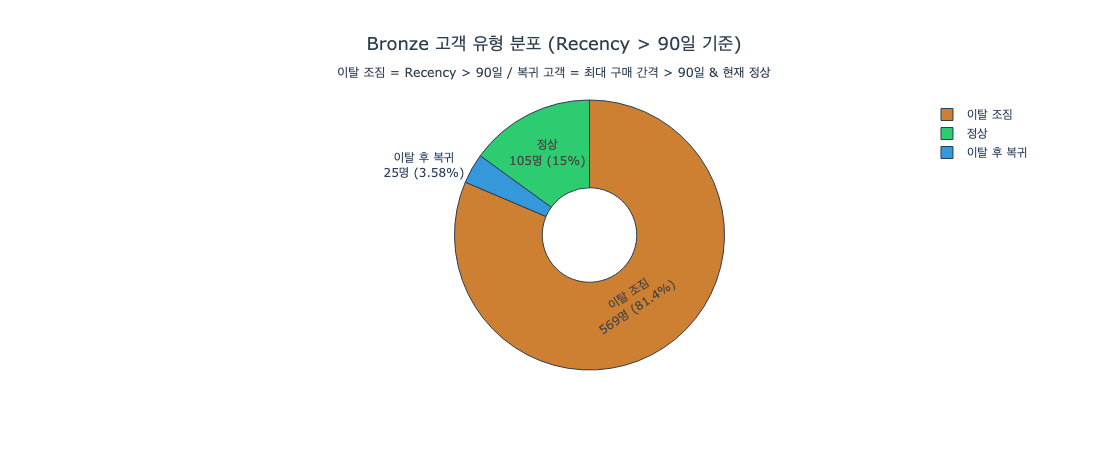

In [19]:
labels_pie = ['정상', '이탈 후 복귀', '이탈 조짐']
values_pie = [total_정상, total_복귀, total_churn]
colors_pie = ['#2ecc71', '#3498db', '#CD7F32']

fig = go.Figure(go.Pie(
    labels=labels_pie,
    values=values_pie,
    marker=dict(colors=colors_pie, line=dict(color='#2c3e50', width=1)),
    texttemplate='%{label}<br>%{value}명 (%{percent})',
    hole=0.35,
))
fig.update_layout(
    title=dict(
        text='Bronze 고객 유형 분포 (Recency > 90일 기준)<br><sub>이탈 조짐 = Recency > 90일 / 복귀 고객 = 최대 구매 간격 > 90일 & 현재 정상</sub>',
        x=0.5, xanchor='center', font=dict(size=18, color='#2c3e50')
    ),
    height=450,
)
fig.show()

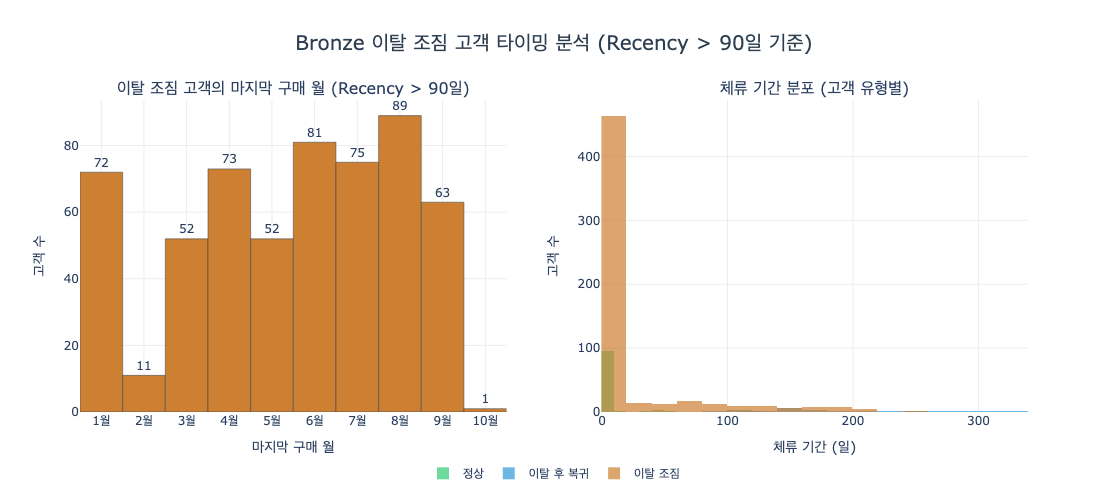

In [20]:
month_labels_churn = {
    1: '1월', 2: '2월', 3: '3월', 4: '4월', 5: '5월', 6: '6월',
    7: '7월', 8: '8월', 9: '9월', 10: '10월', 11: '11월', 12: '12월'
}
churn_monthly['월'] = churn_monthly['마지막구매월'].map(month_labels_churn)

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=['이탈 조짐 고객의 마지막 구매 월 (Recency > 90일)', '체류 기간 분포 (고객 유형별)']
)

fig.add_trace(go.Bar(
    x=churn_monthly['월'],
    y=churn_monthly['이탈고객수'],
    marker=dict(color='#CD7F32', line=dict(color='#2c3e50', width=0.5)),
    text=churn_monthly['이탈고객수'],
    textposition='outside',
    showlegend=False,
), row=1, col=1)

hist_groups = [
    (timing_data[~timing_data['이탈조짐'] & ~timing_data['복귀고객']]['체류기간'], '#2ecc71', '정상'),
    (timing_data[timing_data['복귀고객']]['체류기간'], '#3498db', '이탈 후 복귀'),
    (timing_data[timing_data['이탈조짐']]['체류기간'], '#CD7F32', '이탈 조짐'),
]
for sub, color, name in hist_groups:
    fig.add_trace(go.Histogram(
        x=sub,
        name=name,
        marker_color=color,
        opacity=0.7,
        nbinsx=15,
    ), row=1, col=2)

fig.update_layout(
    title=dict(
        text='Bronze 이탈 조짐 고객 타이밍 분석 (Recency > 90일 기준)',
        font=dict(size=20, color='#2c3e50'), x=0.5, xanchor='center'
    ),
    plot_bgcolor='white',
    height=500,
    barmode='overlay',
    legend=dict(orientation='h', yanchor='top', y=-0.15, xanchor='center', x=0.5)
)
fig.update_xaxes(gridcolor='#ececec')
fig.update_yaxes(gridcolor='#ececec')
fig.update_xaxes(title_text='마지막 구매 월', row=1, col=1)
fig.update_xaxes(title_text='체류 기간 (일)', row=1, col=2)
fig.update_yaxes(title_text='고객 수', row=1, col=1)
fig.update_yaxes(title_text='고객 수', row=1, col=2)
fig.show()

In [21]:
recency_filter = timing_data[timing_data['Recency'] > 90]
seg_filter = timing_data[timing_data['세그먼트'].isin(['이탈 고객', '휴면 고객', '이탈 조짐 고객'])]

print(f"Recency > 90일: {len(recency_filter)}명")
print(f"세그먼트 필터: {len(seg_filter)}명")
print(f"차이: {len(recency_filter) - len(seg_filter)}명")

Recency > 90일: 569명
세그먼트 필터: 472명
차이: 97명


In [22]:
# 세그먼트 필터에 안 잡힌 97명이 어느 세그먼트인지
extra = timing_data[
    (timing_data['Recency'] > 90) &
    (~timing_data['세그먼트'].isin(['이탈 고객', '휴면 고객', '이탈 조짐 고객']))
]
print(extra['세그먼트'].value_counts())

세그먼트
신규 고객        94
놓치면 안될 고객     3
Name: count, dtype: int64


Recency > 90일 기준(569명)과 세그먼트 필터(472명)의 차이 97명은 **신규 고객(94명)·놓치면 안될 고객(3명)** 으로만 구성된다.

- **신규 고객(94명)**: 온보딩군으로 첫 구매 = 마지막 구매인 고객들 — "언제 이탈했냐"가 아닌 "언제 유입됐냐"가 본질이므로 이탈 시점 분석 대상이 아님
- **놓치면 안될 고객(3명)**: 소표본으로 분석 초반에 이미 제외 선언한 그룹

따라서 세그먼트 필터(472명)가 이탈 시점 분석에 더 적합하며, 이하 세그먼트 기준 시각화는 이 근거 위에서 진행된다.

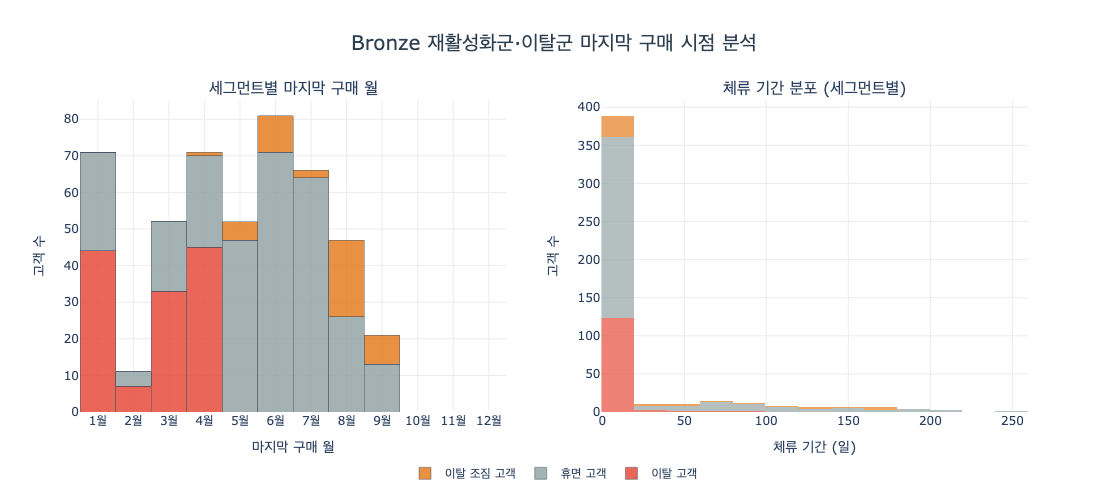

In [23]:
month_labels = {
    1: '1월', 2: '2월', 3: '3월', 4: '4월', 5: '5월', 6: '6월',
    7: '7월', 8: '8월', 9: '9월', 10: '10월', 11: '11월', 12: '12월'
}
monthly_dist['월'] = monthly_dist['마지막구매월'].map(month_labels)
all_months = [month_labels[i] for i in range(1, 13)]

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=['세그먼트별 마지막 구매 월', '체류 기간 분포 (세그먼트별)']
)

seg_h3_order = ['이탈 고객', '휴면 고객', '이탈 조짐 고객']
for seg in seg_h3_order:
    sub = monthly_dist[monthly_dist['세그먼트'] == seg].set_index('월').reindex(all_months, fill_value=0)
    fig.add_trace(go.Bar(
        x=all_months,
        y=sub['고객수'],
        name=seg,
        marker=dict(color=seg_color.get(seg, '#cccccc'), line=dict(color='#2c3e50', width=0.5)),
        opacity=0.85,
    ), row=1, col=1)

for seg in seg_h3_order:
    sub = main3[main3['세그먼트'] == seg]['체류기간']
    fig.add_trace(go.Histogram(
        x=sub,
        name=seg,
        marker_color=seg_color.get(seg, '#cccccc'),
        opacity=0.7,
        nbinsx=15,
        showlegend=False,
    ), row=1, col=2)

fig.update_layout(
    title=dict(
        text='Bronze 재활성화군·이탈군 마지막 구매 시점 분석',
        font=dict(size=20, color='#2c3e50'), x=0.5, xanchor='center'
    ),
    plot_bgcolor='white',
    height=500,
    barmode='stack',
    legend=dict(orientation='h', yanchor='top', y=-0.15, xanchor='center', x=0.5)
)
fig.update_xaxes(gridcolor='#ececec')
fig.update_yaxes(gridcolor='#ececec')
fig.update_xaxes(title_text='마지막 구매 월', row=1, col=1)
fig.update_xaxes(title_text='체류 기간 (일)', row=1, col=2)
fig.update_yaxes(title_text='고객 수', row=1, col=1)
fig.update_yaxes(title_text='고객 수', row=1, col=2)
fig.show()

> ### 가설 3 검증 결과: 채택
>
> **1. Recency > 90일 기준 — 이탈 조짐 고객 분포**
>
> | 구분 | 고객 수 | 비중 |
> | :--- | :---: | :---: |
> | 정상 (Recency ≤ 90일, 최대 간격 ≤ 90일) | 105명 | 15.0% |
> | 이탈 후 복귀 (최대 간격 > 90일, 현재 정상) | 25명 | 3.6% |
> | 이탈 조짐 (Recency > 90일) | 569명 | 81.4% |
> | **전체** | **699명** | **100%** |
>
> Bronze 고객 **81.4%(569명)** 이 이탈 조짐 상태 — Gold(53.5%)·Silver(59.6%)보다 높아 Bronze가 이탈 위험이 가장 심각한 등급임을 재확인한다.
> 이탈 조짐 고객의 마지막 구매는 **8월 최다(89명, 15.6%)** 로 여름(6-9월, 308명, 54.1%)에 집중된다.
>
> **2. 세그먼트 기준 — 그룹별 이탈 시기 분리**
>
> | 세그먼트 | 그룹 | 집중 시기 | 집중기간 인원 | 총 고객 수 | 핵심 패턴 |
> | :---: | :---: | :---: | :---: | :---: | :--- |
> | 이탈 고객 | 이탈군 | **1-4월** (100%) | 129명 | 129명 | 1-4월에만 분포, 연중 재방문 전무 |
> | 휴면 고객 | 재활성화군 | **5-7월** (61.5%) | 182명 | 296명 | 1-9월(296명 전원), 5-7월 집중, 6월 최다(71명, 24.0%) |
> | 이탈 조짐 고객 | 재활성화군 | **6-9월** (87.2%) | 41명 | 47명 | 4-9월(47명 전원), 6-9월 집중, 8월 최다(21명, 44.7%) |
>
> **핵심 요약**
> 이탈군(이탈 고객)은 1-4월에만, 재활성화군(휴면·이탈 조짐)은 연중 전 구간에 분포하되 여름에 집중된다.
>
> - **이탈 고객 (1-4월 100%, 129명/129명)**: 1월(44명)·4월(45명) 최다 — 1-4월에만 분포하여 연초 구매 후 연중 재방문이 전무한 구조적 이탈이다.
> - **휴면 고객 (5-7월 61.5%, 182명/296명)**: 1-9월 전 구간에 분포하나 6월(71명, 24.0%)·7월(64명) 중심의 여름 피크가 뚜렷하다. 재활성화 최적 타이밍은 10-11월이다.
> - **이탈 조짐 고객 (6-9월 87.2%, 41명/47명)**: 4-9월에만 분포하며(4월 1명·5월 5명 포함), 6-9월(41명)에 강하게 집중. 8월 최다(21명, 44.7%) — 기준일(12-31) 기준 마지막 구매 3-6개월 전 → 재활성화 개입이 우선 필요한 세그먼트.
>
> **⚠️ 데이터 해석의 한계**
> - 단년도(1개년) 데이터 특성상 계절성 패턴의 반복 여부는 다년도 데이터로 재검증이 필요하다.

---
## 결론 및 핵심 인사이트

Bronze는 전체 고객의 **47.6%(699명)**, 매출 **11.0%** 를 담당하는 이탈 위험 등급이다. 재방문율 26.3%는 Silver(57.0%) 대비 30.7%p 낮고, 4명 중 3명이 단 하루만 구매하고 재방문하지 않는다.

---

### 발견 1 — 이탈 고객(6.2%)이 전체 재방문율을 끌어내리며, RFM 점수 구간별 단조 증가(15.1%→37.6%)로 재확인된다 _(가설 1)_

이탈 고객(R=1, Recency 290일)이 Bronze 내 최저 재방문율(6.2%)로 전체를 끌어내린다. RFM 점수 구간별로도 동일한 방향의 패턴이 확인된다.

| 세그먼트 | 재방문율 | Recency 중앙값 | 그룹 |
|---------|:------:|:-----------:|:---:|
| 이탈 조짐 고객 | **42.6%** | 144.0일 | 재활성화군 |
| 휴면 고객 | 30.1% | 202.0일 | 재활성화군 |
| 신규 고객 | 29.5% | 81.0일 | 온보딩군 |
| 이탈 고객 | **6.2%** | 290.0일 | 이탈군 |

- **이탈 고객**: Recency 290일로 Bronze 내 최장 미구매 기간 — Bronze 전체 재방문율을 끌어내린다
- **이탈 조짐 고객**: 재방문율 42.6%로 주요 세그먼트 중 최고 — 재활성화 우선 대응 대상
- **RFM 점수 구간별 단조 증가**: 20-30(15.1%) → 30-40(31.5%) → 40-50(37.6%) — 세그먼트 편차와 동일한 방향으로 작동. 20-30 구간에 이탈 고객 129명(45%)이 집중되어 해당 구간 재방문율을 15.1%로 끌어내리는 구조적 원인이다
- **30-40 구간이 단기 Silver 전환 최유망**: 이탈 조짐 고객이 이 구간에 집중(47명 중 46명, 재방문율 43.5%) — 재방문율 향상 → Frequency 증가 → RFM 점수 상승 → Silver 전환 진전의 선순환이 성립한다

---

### 발견 2 — Silver 전환 갭과 지출 격차 모두 Frequency가 결정 — 실질 타깃은 휴면 고객이다 _(가설 2)_

| 세그먼트 | Silver 갭 | 고객수 | Monetary 중앙값 | 재방문율 |
|---------|:--------:|:-----:|:-----------:|:------:|
| 가망 고객 | **7.1점** | 4명 | `$593` | 50.0% |
| 놓치면 안될 고객 | **11.6점** | 3명 | **`$2,098`** | 0.0% |
| 휴면 고객 | **12.0점** | 296명 | **`$1,013`** | 30.1% |
| 신규 고객 | 13.9점 | 220명 | `$440` | 29.5% |
| 이탈 조짐 고객 | 15.2점 | 47명 | `$579` | 42.6% |
| 이탈 고객 | **30.0점** | 129명 | `$347` | 6.2% |

Silver 전환 갭은 Recency가 아닌 M·F와 관련성이 높다. Recency 202일의 침묵에도 M=2·F=2인 휴면(갭 12.0점)이 Recency 81일의 신규(갭 13.9점)보다 Silver에 더 가깝다. **볼륨·가치를 함께 고려하면 휴면(296명, 갭 12.0점, `$1,013`)이 실질적 최우선 타깃**이다.

- **Bronze-Silver 지출 격차 분해**: Monetary 격차(3.27x) ≈ Frequency(2.94x) × 단가(1.20x) — 격차의 대부분이 구매 빈도에서 비롯된다. 고가 제품 전략보다 재방문 빈도 증대가 약 2.5배 효과적인 Silver 전환 전략이다
- **놓치면 안될 고객** (3명, 갭 11.6점): Silver 갭이 두 번째로 작지만 Recency 268일로 즉각 이탈 방어 개입이 필요하다

---

### 발견 3 — 이탈은 시기별로 분리되어 단일 캠페인으로 대응이 제한적 _(가설 3)_

이탈군(이탈 고객)은 연초, 재활성화군(휴면·이탈 조짐)은 상반기-여름으로 **그룹별 마지막 구매 시기가 완전히 분리**된다.

- **이탈 고객 (이탈군)**: 1-4월 집중(100%) — 1월(44명)·4월(45명) 최다. 연초 구매 후 연간 재방문 전무
- **휴면 고객 (재활성화군)**: 5-7월 집중(61.5%) — 6월(71명)·7월(64명) 최다. 재활성화 최적 타이밍은 10-11월
- **이탈 조짐 고객 (재활성화군)**: 6-9월 집중(87.2%) — 8월 최다(21명). 재활성화군 중 가장 최근까지 구매 → 개입 우선 필요

Gold·Silver에서 관찰된 계절성 패턴과 달리 Bronze는 **이탈 시기 자체가 그룹·세그먼트별로 완전히 분리**되어 있다.

---

> **Bronze 등급 핵심 전략**
>
> 1. **최대 볼륨 재활성화**: 휴면(296명, `$1,013`) → 여름 마지막 구매 후 10-11월 재활성화 캠페인
> 2. **우선 대응 대상**: 이탈 조짐(47명, RFM 34.8) → Recency 회복 집중 접촉 (마지막 구매 후 90-150일)
> 3. **초기 이탈 방어**: 신규(220명) → 첫 구매 후 2-4주 내 리마인더로 2차 구매 유도 (빈도 1→2회)
> 4. **RFM 점수 집중 구간**: 30-40 구간(241명) — 이탈 조짐 47명 중 46명이 이 구간에 집중하며 재방문율 43.5%로 견인 — 이 구간의 재방문율 제고가 Bronze 전체 재방문율 향상에 가장 효과적

> ✅ **세그먼트별 액션 아이템**
>
> **가망 고객 (4명, Silver 갭 7.1점)**
> - Bronze 내 Silver 전환 가장 근접 세그먼트(갭 7.1점) + 재방문율 50.0%
> - Recency 22일로 최근 활성 — 즉각적 Silver 업셀 캠페인 최우선 대상
> - Frequency 증대(F=2→3) 또는 Monetary 상승(M=1→2) 중 하나만 달성해도 갭 축소 가능
>
> **휴면 고객 (296명, Silver 갭 12.0점)**
> - Bronze 최고가치(`$1,013`) + 최대 볼륨 — 재활성화 ROI 최대
> - 여름(5-7월) 마지막 구매 이후 → 10-11월 "다시 만나요" 복귀 쿠폰 집행
> - F·M=2→3 점프 시 RFM 점수 +6-8점 → Silver 갭 12.0점 → 4.0점으로 축소
>
> **이탈 조짐 고객 (47명, Silver 갭 15.2점)**
> - 재방문율 42.6% — Bronze 내 주요 세그먼트 중 최고 재방문율
> - Recency 중앙값 144일 → 180일 이전 접촉 시 재방문 가능성 높음
> - "돌아오면 X% 할인" 한정 제안으로 Recency 회복 유도
>
> **신규 고객 (220명, Silver 갭 13.9점)**
> - R=4(최근성 높음)이나 F·M=1로 최저가치 — 재방문 동기 부재가 핵심 문제
> - 첫 구매 후 14-30일 내 "두 번째 구매 혜택" 자동 트리거 설정
> - Frequency 1→2회 달성이 재방문 습관 형성의 첫 단계
>
> **💸 놓치면 안될 고객 (3명, Silver 갭 11.6점)**
> - Bronze 최고가치(`$2,098`) + Recency 268일로 사실상 완전 이탈 위험
> - 대규모 캠페인 대신 1:1 맞춤 VIP 접촉 — "고객님의 이전 구매를 기억합니다" 개인화 메시지
> - 재방문 1회 달성을 1단계 목표로 설정 (Silver 전환보다 이탈 방어 우선)
>
> **이탈 고객 (129명, Silver 갭 30.0점)**
> - Recency 중앙값 290일로 단기 재활성화 어려움
> - 대규모 캠페인 ROI 낮음 — 소규모 재참여 테스트(이메일 오픈율 모니터링)로 반응 확인 후 집행
> - 단기 Silver 전환 목표보다 Bronze 잔류 + 재방문 1회 달성을 1단계 목표로 설정

> 🧪 **A/B 테스트 제안**
>
> - **실험 단위**: 고객 단위 랜덤 할당
> - **표본 한계**: Bronze 699명 — 세그먼트당 47-296명, 3-6개월 누적 후 판단 권장
>
> **휴면 고객 — 재활성화 타이밍 (296명)**
> - 가설: 마지막 구매 후 90-120일 선제 접촉이 150일+ 이후보다 재방문율이 높을 것이다
> - A그룹: 150일+ 경과 후 접촉 / B그룹: 90-120일 시점 선제 접촉
> - **주요 지표**: 발송 후 30일 내 재방문율 / **보조 지표**: AOV, Recency 단축 일수
>
> **신규 고객 — 2차 구매 유도 타이밍 (220명)**
> - 가설: 첫 구매 후 14일 내 리마인더가 30일 후 접촉보다 2차 구매율이 높을 것이다
> - A그룹: 첫 구매 후 30일 후 접촉 / B그룹: 14일 내 자동 리마인더
> - **주요 지표**: 발송 후 30일 내 2차 구매율 / **보조 지표**: Frequency 증가, AOV